Libraries

In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV, validation_curve



import datasets

In [2]:
df_tr=pd.read_csv('https_training.csv')
df_te=pd.read_csv('https_test.csv')

df_tr_c=df_tr.copy()
df_te_c=df_te.copy()



df_tr_c = df_tr_c.dropna(how='all')
df_te_c = df_te_c.dropna(how='all')


le = LabelEncoder()

df_tr_c['label'] = le.fit_transform(df_tr_c['label'])
df_te_c['label'] = le.transform(df_te_c['label'])


for i, label in enumerate(le.classes_):
    print(f"Class {i}: {label}")

y_target='label'

categorial_features=['time', 'c_ip']

columns_to_drop = [y_target] + categorial_features

X_train = df_tr_c.drop(columns=columns_to_drop, axis=1) 
y_train = df_tr_c[y_target]
X_test = df_te_c.drop(columns=columns_to_drop, axis=1)
y_test = df_te_c[y_target]


scaler=StandardScaler()
X_train_s = scaler.fit_transform(X_train) 
X_test_s = scaler.transform(X_test)

Classe 0: _other
Classe 1: adnxs.com
Classe 2: ads-twitter.com
Classe 3: chartbeat.com
Classe 4: contextweb.com
Classe 5: disqus.com
Classe 6: everesttech.net
Classe 7: fastly-insights.com
Classe 8: fastly.net
Classe 9: ftcdn.net
Classe 10: giphy.com
Classe 11: githubusercontent.com
Classe 12: krxd.net
Classe 13: newrelic.com
Classe 14: outbrain.com
Classe 15: pinterest.com
Classe 16: polyfill.io
Classe 17: redd.it
Classe 18: reddit.com
Classe 19: scdn.co
Classe 20: slack-edge.com
Classe 21: taboola.com
Classe 22: twimg.com
Classe 23: twitch.tv
Classe 24: twitchcdn.net
Classe 25: vimeocdn.com


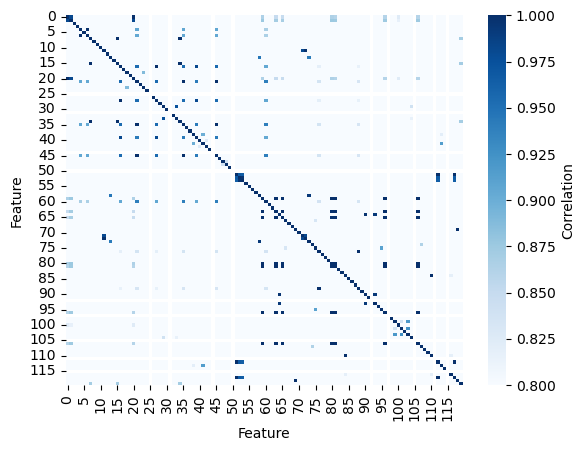

48 features are removed


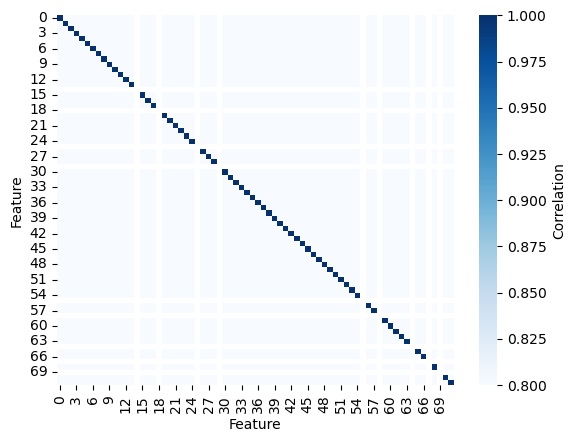

/tmp/ipykernel_72/2897408379.py:70: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  y_test_flat = y_test.ravel()
/tmp/ipykernel_72/2897408379.py:71: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  y_train_flat = y_train.ravel()
/opt/conda/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logist

              precision    recall  f1-score   support

           0       0.57      0.62      0.59     34777
           1       0.49      0.49      0.49      2942
           2       0.25      0.21      0.23      1135
           3       0.48      0.42      0.45      1717
           4       0.37      0.39      0.38      2383
           5       0.32      0.19      0.24      3246
           6       0.43      0.36      0.39      2894
           7       0.45      0.69      0.54       686
           8       0.28      0.19      0.23      1455
           9       0.92      0.87      0.89      1607
          10       0.51      0.63      0.56      1730
          11       0.48      0.40      0.43      4477
          12       0.58      0.55      0.56     11171
          13       0.37      0.26      0.30      1604
          14       0.30      0.27      0.28      4426
          15       0.26      0.10      0.14      1542
          16       0.17      0.08      0.11      1102
          17       0.72    

In [3]:

columns= [i for i in range(X_train_s.shape[1])]
df_tmp = pd.DataFrame(X_train_s, columns=columns)
correlation_matrix = df_tmp.corr().abs()


plt.figure()
sns.heatmap(correlation_matrix, cmap='Blues', vmin=0.8, vmax=1, cbar_kws={'label':'Correlation'})
plt.xlabel('Feature')
plt.ylabel('Feature')
plt.show()



c = correlation_matrix[correlation_matrix>0.8]
s = c.unstack()
so = s.sort_values(ascending=False).reset_index()


so = so[(so[0].isnull()==False) & (so["level_0"] != so["level_1"])]

to_be_deleted = []
candidates = list(so["level_0"])


subset_so = so
for candidate in candidates:
    if (candidate in list(subset_so["level_0"])): 
        to_be_deleted.append(candidate)
        subset_so = subset_so[(subset_so["level_0"] != candidate) & (subset_so["level_1"] != candidate)]

columns_to_keep = np.ones(X_train_s.shape[1], dtype=bool)
columns_to_keep[to_be_deleted] = False


X_train_s = X_train_s[:, columns_to_keep]
X_test_s = X_test_s[:, columns_to_keep]

columns= [i for i in range(X_train_s.shape[1])]
df_tmp = pd.DataFrame(X_train_s, columns=columns)
correlation_matrix = df_tmp.corr().abs()

plt.figure()
sns.heatmap(correlation_matrix, cmap='Blues', vmin=0.8, vmax=1, cbar_kws={'label':'Correlation'})
plt.xlabel('Feature')
plt.ylabel('Feature')
plt.show()



#Models default training


knn = KNeighborsClassifier()

log_reg = LogisticRegression()

rand_forest = RandomForestClassifier()

y_test_flat = y_test.ravel()
y_train_flat = y_train.ravel()

knn.fit(X_train_s, y_train_flat)
log_reg.fit(X_train_s, y_train_flat)
rand_forest.fit(X_train_s, y_train_flat)

y_train_pred_knn = knn.predict(X_train_s)
y_train_pred_lr  = log_reg.predict(X_train_s)
y_train_pred_rf  = rand_forest.predict(X_train_s)

y_test_pred_knn = knn.predict(X_test_s)
y_test_pred_lr  = log_reg.predict(X_test_s)
y_test_pred_rf  = rand_forest.predict(X_test_s)




print(classification_report(y_test_flat, y_test_pred_knn))
print(classification_report(y_train_flat, y_train_pred_knn))

print(classification_report(y_test_flat, y_test_pred_lr))
print(classification_report(y_train_flat, y_train_pred_lr))

print(classification_report(y_test_flat, y_test_pred_rf))
print(classification_report(y_train_flat, y_train_pred_rf))






Distributions of classes on the datasets

=== Distribuzione Label nel Training Set ===
label
0     35083
1      3839
2      1325
3      1413
4      2824
5      3173
6      3408
7      1309
8      1869
9      3455
10     3886
11     4271
12    11144
13     2182
14     5637
15     1967
16     1270
17     3085
18     3457
19    25322
20     1064
21    21018
22     1024
23     2383
24     1436
25     1019
Name: count, dtype: int64

=== Distribuzione Label nel Test Set ===
label
0     34777
1      2942
2      1135
3      1717
4      2383
5      3246
6      2894
7       686
8      1455
9      1607
10     1730
11     4477
12    11171
13     1604
14     4426
15     1542
16     1102
17     1855
18     1585
19    13223
20      651
21    15764
22      771
23      644
24      228
25      965
Name: count, dtype: int64


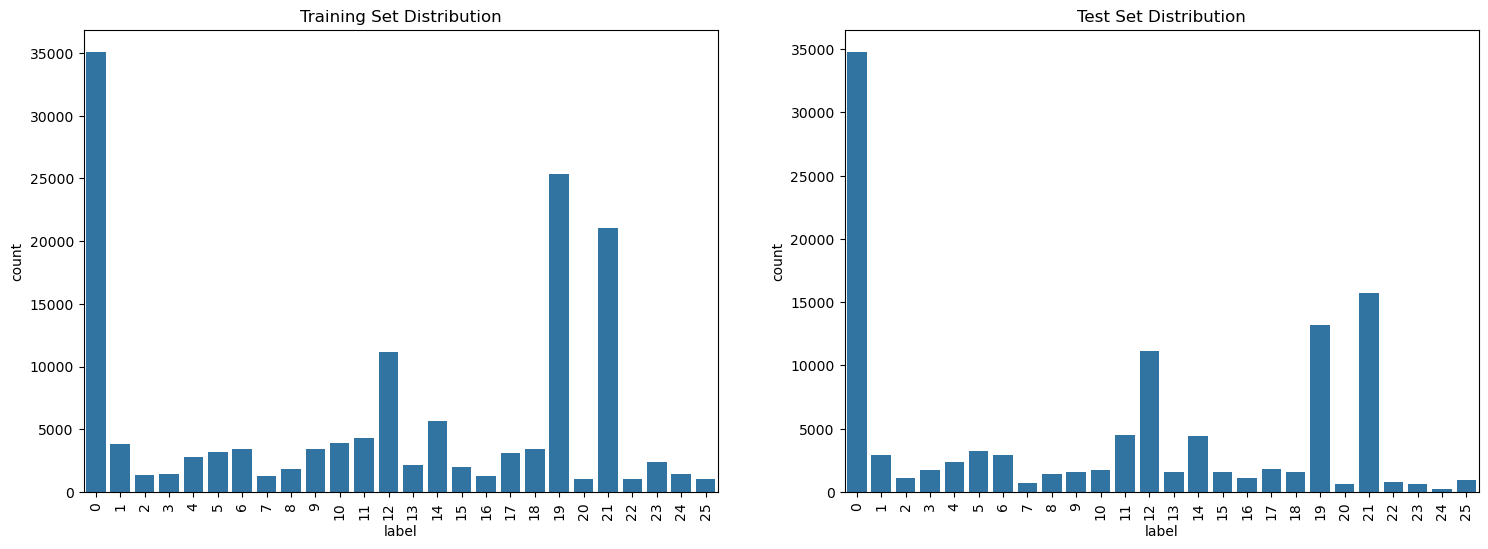

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.countplot(x='label', data=df_tr_c, ax=axes[0], order=sorted(df_tr_c['label'].unique()))
axes[0].set_title('Training Set Distribution')
axes[0].tick_params(axis='x', rotation=90) 

sns.countplot(x='label', data=df_te_c, ax=axes[1], order=sorted(df_te_c['label'].unique()))
axes[1].set_title('Test Set Distribution')
axes[1].tick_params(axis='x', rotation=90)

plt.show()

Confusion matrixes of the default training

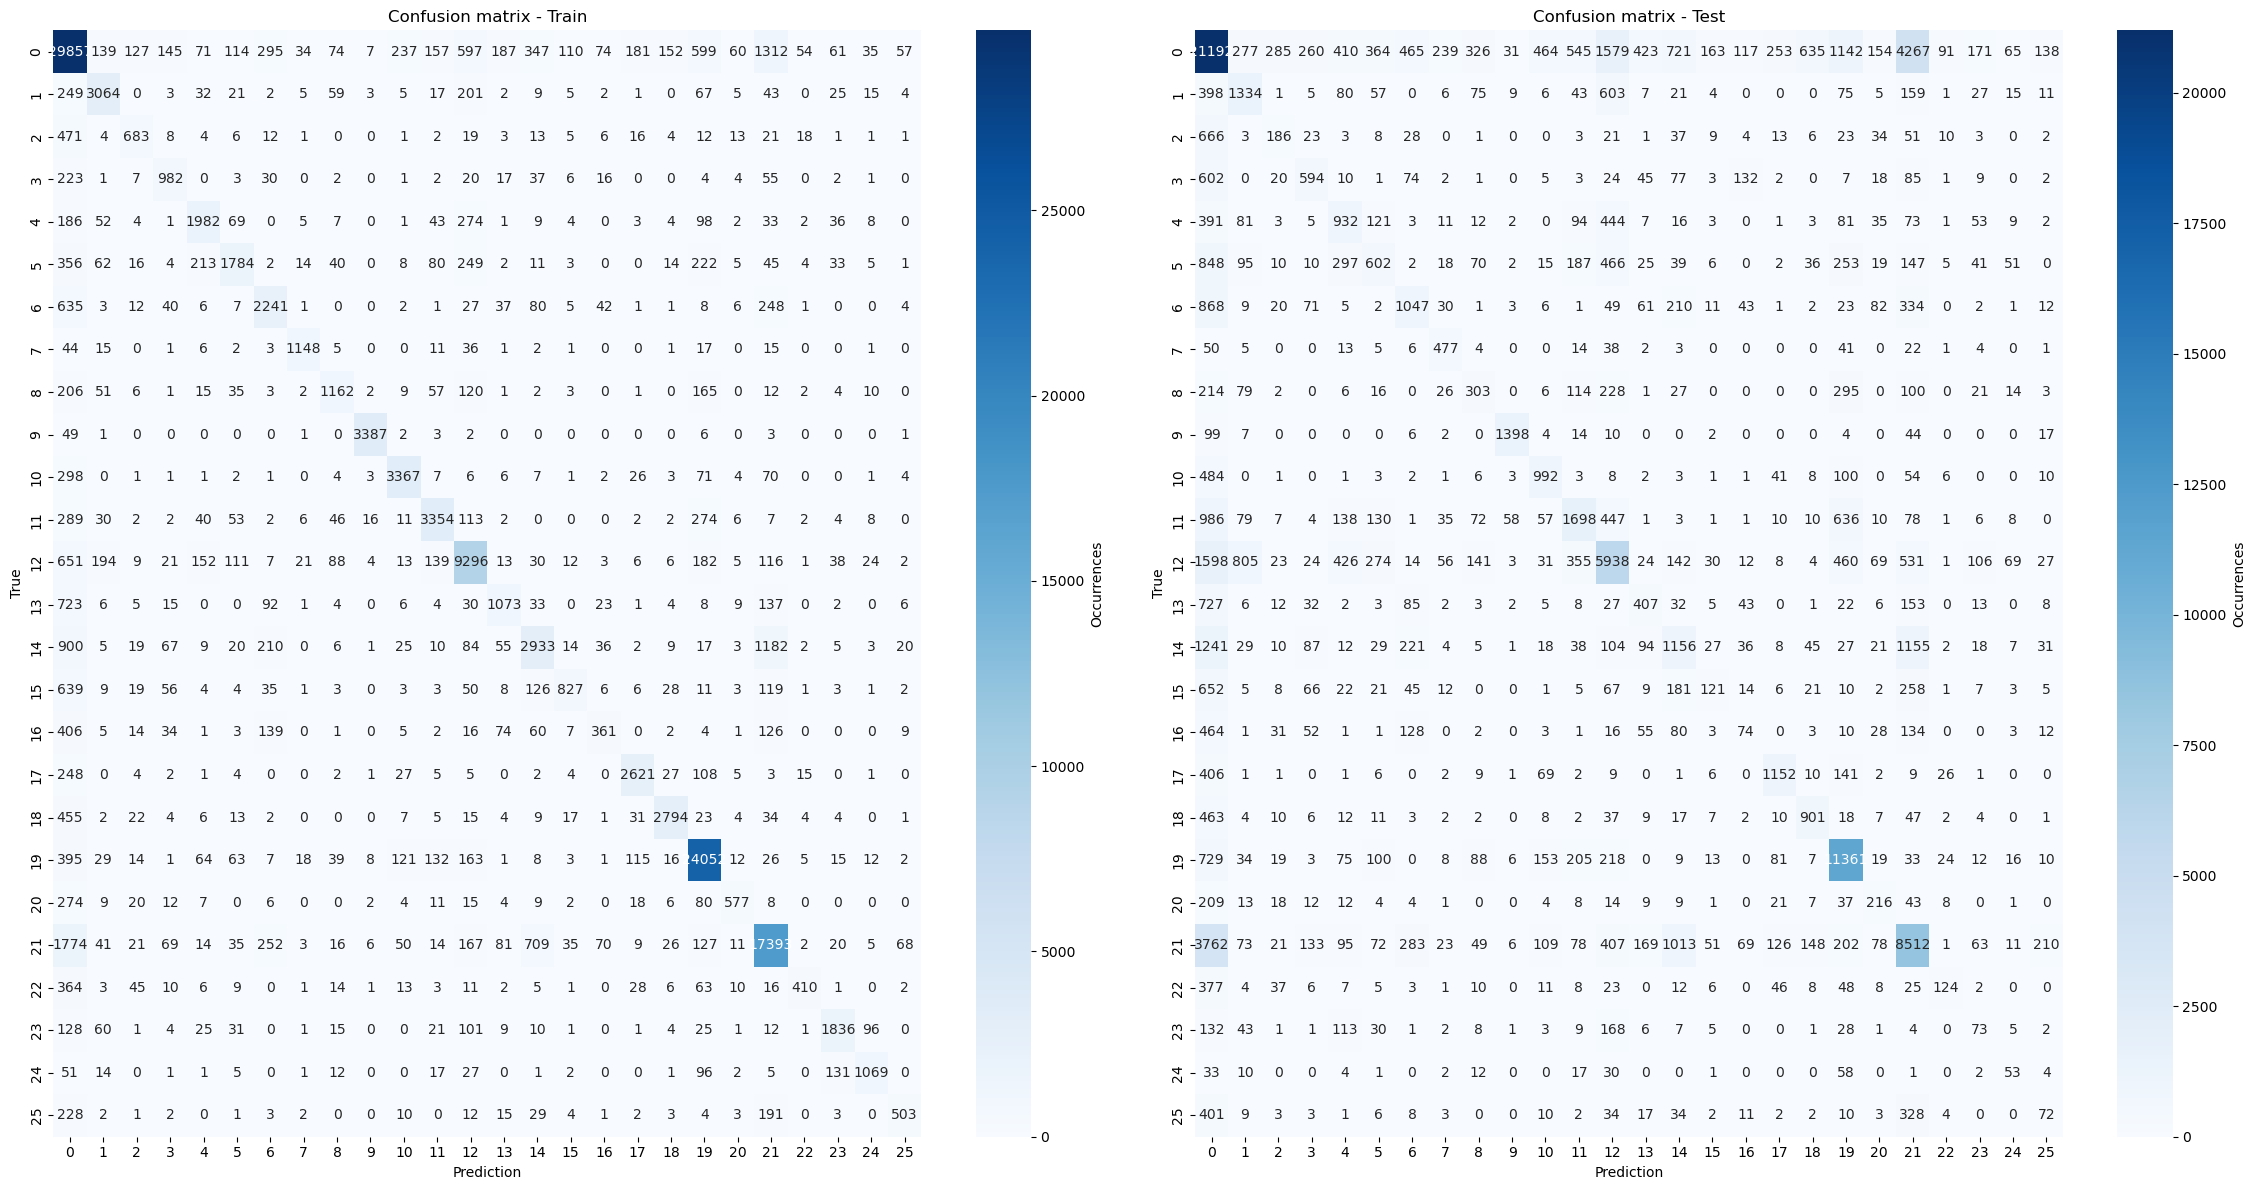

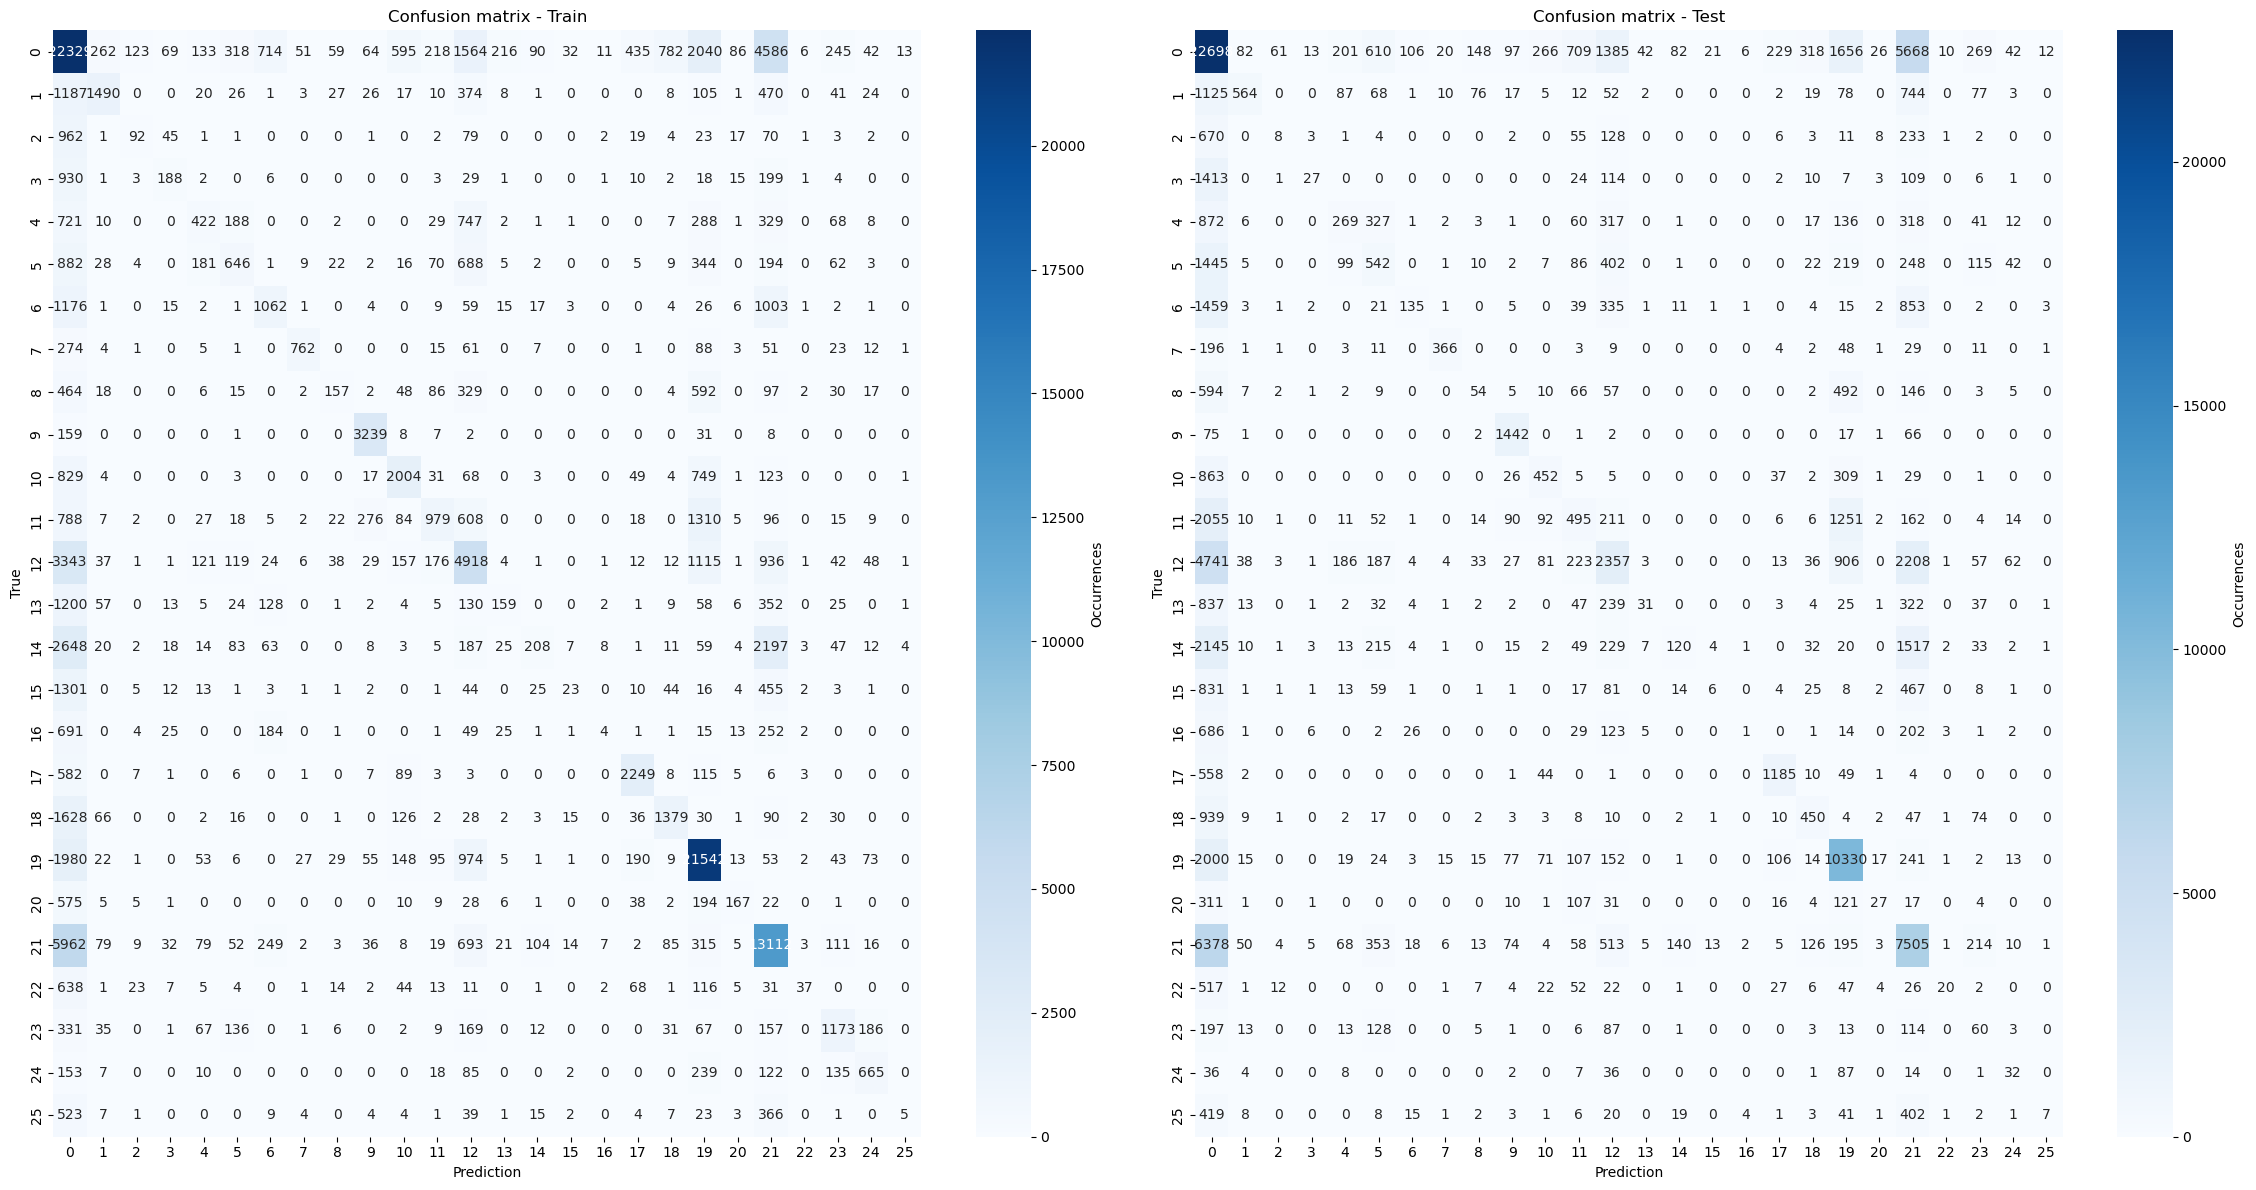

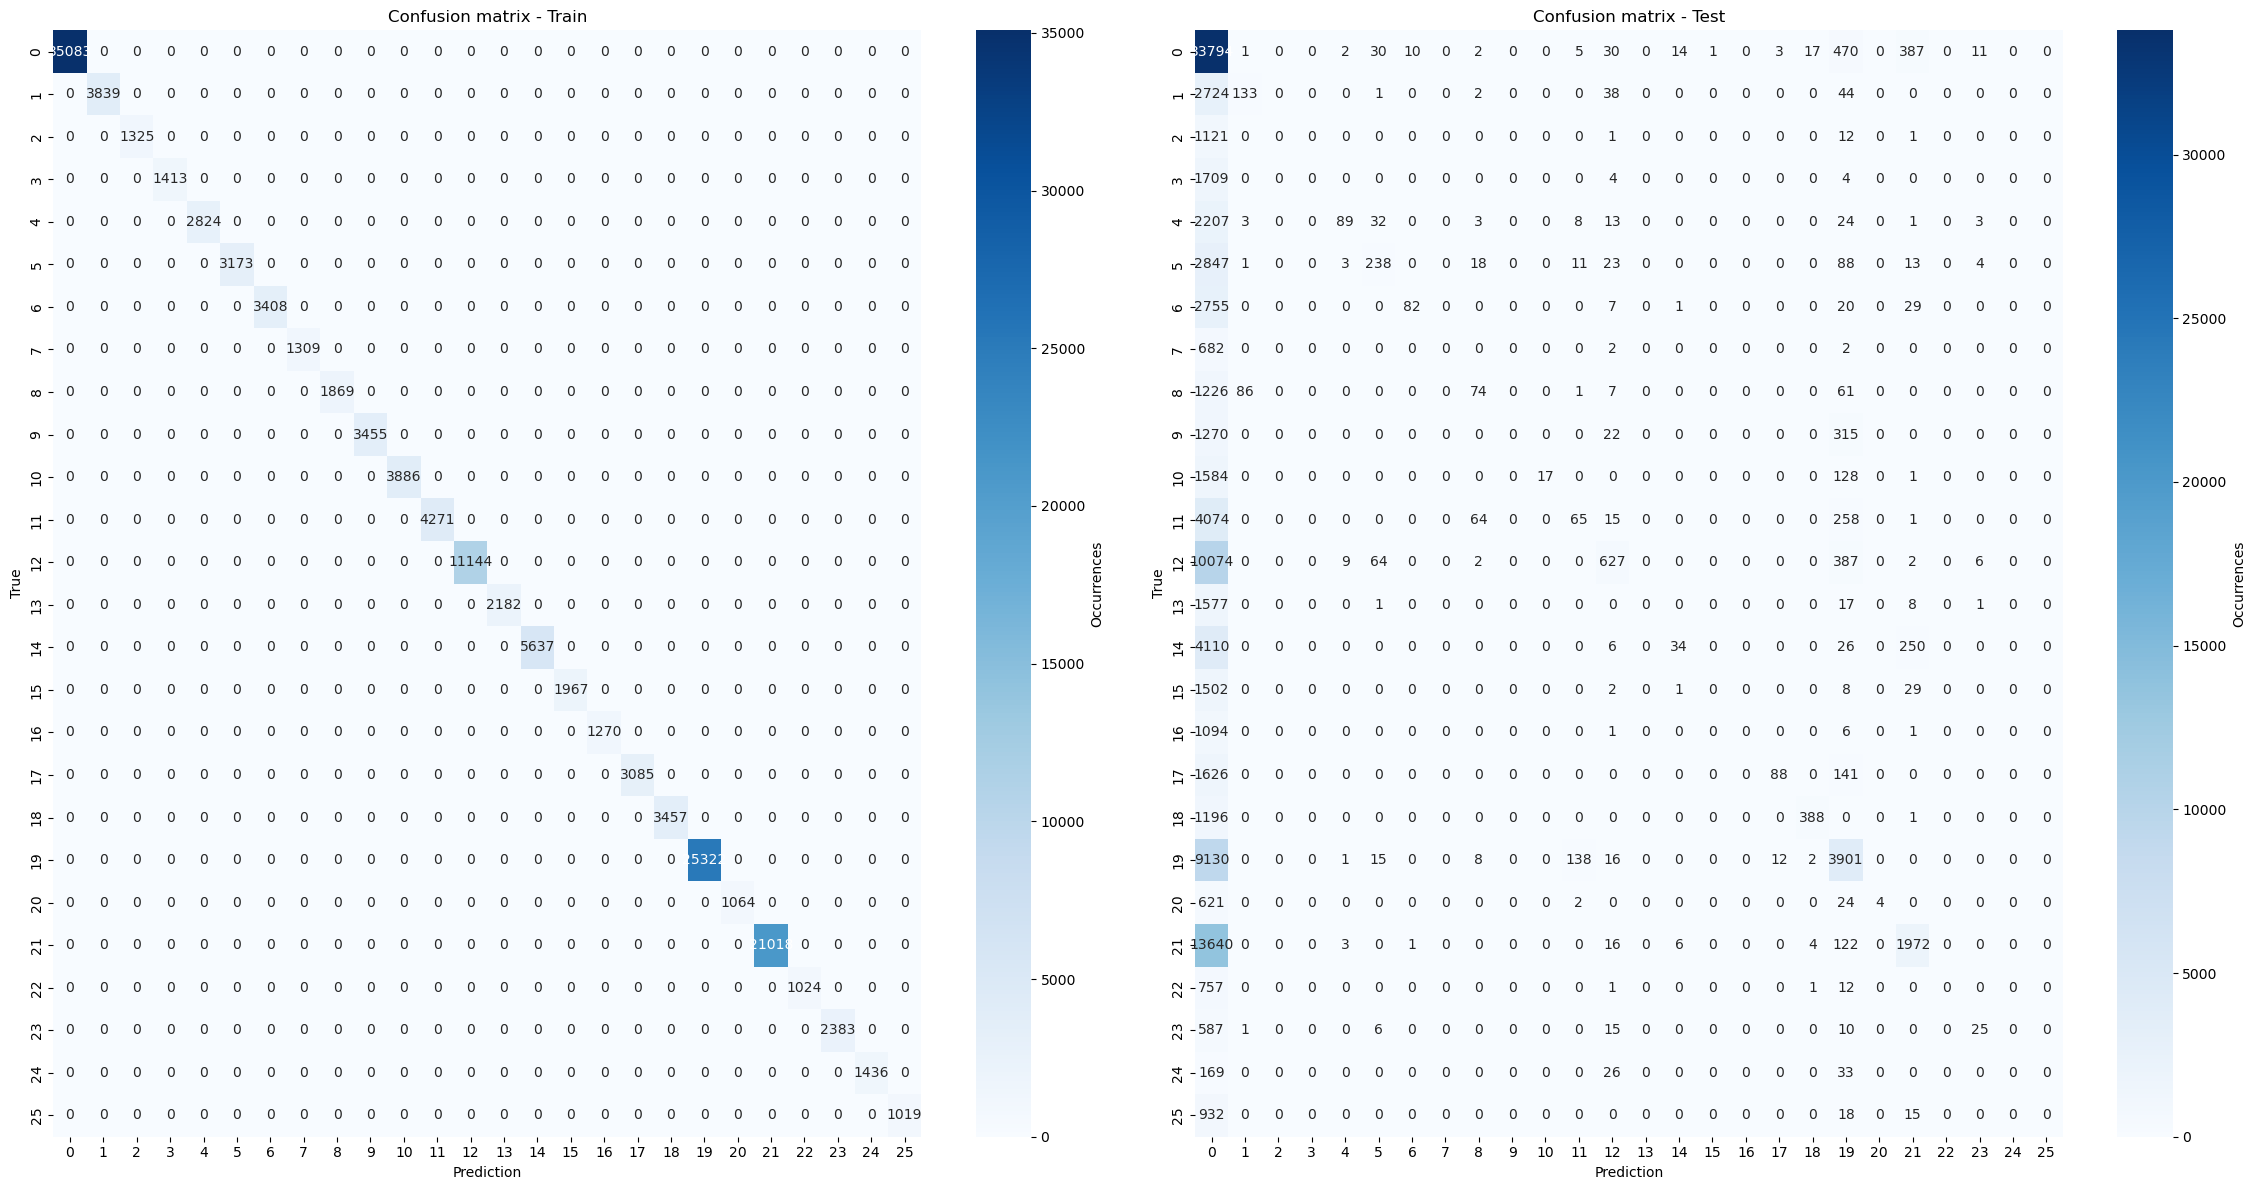

In [6]:

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(23, 12))

confusion_train = confusion_matrix(y_train_flat, y_train_pred_knn)
sns.heatmap(confusion_train, cmap='Blues', annot=True, ax=ax1, cbar_kws={'label':'Occurrences'}, fmt='d')
ax1.set_xlabel('Prediction')
ax1.set_ylabel('True')
ax1.set_title('Confusion matrix knn - Train')

confusion_test = confusion_matrix(y_test_flat, y_test_pred_knn)
sns.heatmap(confusion_test, cmap='Blues', annot=True, ax=ax2, cbar_kws={'label':'Occurrences'}, fmt='d')
ax2.set_xlabel('Prediction')
ax2.set_ylabel('True')
ax2.set_title('Confusion matrix knn- Test')

plt.tight_layout()
plt.show()



fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(23, 12))

confusion_train = confusion_matrix(y_train_flat, y_train_pred_lr)
sns.heatmap(confusion_train, cmap='Blues', annot=True, ax=ax1, cbar_kws={'label':'Occurrences'}, fmt='d')
ax1.set_xlabel('Prediction')
ax1.set_ylabel('True')
ax1.set_title('Confusion matrix lr- Train')

confusion_test = confusion_matrix(y_test_flat, y_test_pred_lr)
sns.heatmap(confusion_test, cmap='Blues', annot=True, ax=ax2, cbar_kws={'label':'Occurrences'}, fmt='d')
ax2.set_xlabel('Prediction')
ax2.set_ylabel('True')
ax2.set_title('Confusion matrix lr- Test')

plt.tight_layout()
plt.show()


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(23, 12))

confusion_train = confusion_matrix(y_train_flat, y_train_pred_rf)
sns.heatmap(confusion_train, cmap='Blues', annot=True, ax=ax1, cbar_kws={'label':'Occurrences'}, fmt='d')
ax1.set_xlabel('Prediction')
ax1.set_ylabel('True')
ax1.set_title('Confusion matrix rf- Train')

confusion_test = confusion_matrix(y_test_flat, y_test_pred_rf)
sns.heatmap(confusion_test, cmap='Blues', annot=True, ax=ax2, cbar_kws={'label':'Occurrences'}, fmt='d')
ax2.set_xlabel('Prediction')
ax2.set_ylabel('True')
ax2.set_title('Confusion matrix rf- Test')
s
plt.tight_layout()
plt.show()

In [5]:

rf = RandomForestClassifier(random_state=42)

param_dist = {
    'n_estimators': [100, 200, 300, 500],        
    'max_depth': [None, 10, 20, 30, 40],        
    'min_samples_split': [2, 5, 10],             
    'min_samples_leaf': [1, 2, 4],               # min samples , less overfitting
    'class_weight': ['balanced', 'balanced_subsample', None] 
}


search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=20,             
    cv=3,                  
    scoring='f1_weighted', 
    verbose=2,
    n_jobs=-1,             
    random_state=42
)

search.fit(X_train, y_train)

# Results
print(f"Best parameters found: {search.best_params_}")
print(f"Best F1 Weighted found: {search.best_score_:.4f}")

best_rf = search.best_estimator_
y_pred = best_rf.predict(X_test)

target_names = [f"Classe {i}" for i in range(26)] 
print(classification_report(y_test, y_pred, target_names=target_names))

Inizio la ricerca dei parametri...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
[CV] END class_weight=balanced_subsample, max_depth=10, min_samples_leaf=2, min_samples_split=2, n_estimators=200; total time= 1.5min
[CV] END class_weight=balanced, max_depth=20, min_samples_leaf=1, min_samples_split=5, n_estimators=200; total time= 2.5min


/opt/conda/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV] END class_weight=balanced_subsample, max_depth=10, min_samples_leaf=2, min_samples_split=2, n_estimators=200; total time= 1.5min
[CV] END class_weight=balanced, max_depth=20, min_samples_leaf=1, min_samples_split=5, n_estimators=200; total time= 2.5min
[CV] END class_weight=None, max_depth=40, min_samples_leaf=2, min_samples_split=5, n_estimators=200; total time= 2.4min
[CV] END class_weight=balanced_subsample, max_depth=30, min_samples_leaf=1, min_samples_split=10, n_estimators=200; total time= 2.7min
[CV] END class_weight=balanced, max_depth=20, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time= 2.5min
[CV] END class_weight=balanced_subsample, max_depth=40, min_samples_leaf=2, min_samples_split=5, n_estimators=300; total time= 4.1min
[CV] END class_weight=balanced, max_depth=20, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time= 2.5min
[CV] END class_weight=balanced_subsample, max_depth=40, min_samples_leaf=2, min_samples_split=5, n_estima

rf overfitting and others underfitting


Calcolo della Validation Curve per n_estimators...


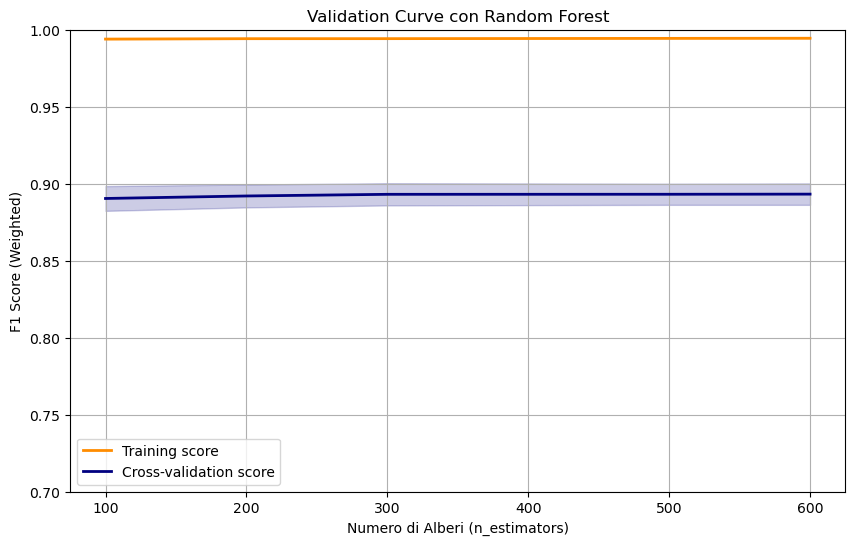

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import validation_curve


param_name = "n_estimators"
param_range = [100, 200, 300, 500, 600] 



train_scores, test_scores = validation_curve(
    best_rf_model,        
    X_train, y_train,     
    param_name=param_name, 
    param_range=param_range,
    cv=3,                 
    scoring="f1_weighted",
    n_jobs=-1            
)


train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)


plt.figure(figsize=(10, 6))
plt.title("Validation Curve con Random Forest")
plt.xlabel(f"Numero di Alberi ({param_name})")
plt.ylabel("F1 Score (Weighted)")
plt.ylim(0.7, 1.0) 
lw = 2
 
plt.plot(param_range, train_scores_mean, label="Training score",
             color="darkorange", lw=lw)
plt.fill_between(param_range, train_scores_mean - train_scores_std,
                 train_scores_mean + train_scores_std, alpha=0.2,
                 color="darkorange")


plt.plot(param_range, test_scores_mean, label="Cross-validation score",
             color="navy", lw=lw)
plt.fill_between(param_range, test_scores_mean - test_scores_std,
                 test_scores_mean + test_scores_std, alpha=0.2,
                 color="navy")

plt.legend(loc="best")
plt.grid(True)
plt.show()

Addestramento del modello Random Forest Ottimizzato in corso...
Generazione predizioni...

--- CLASSIFICATION REPORT (Modello Ottimizzato) ---
              precision    recall  f1-score   support

    Classe 0       0.86      0.82      0.84     34777
    Classe 1       0.94      0.90      0.92      2942
    Classe 2       0.91      0.87      0.89      1135
    Classe 3       0.91      0.95      0.93      1717
    Classe 4       0.87      0.86      0.87      2383
    Classe 5       0.79      0.73      0.76      3246
    Classe 6       0.92      0.92      0.92      2894
    Classe 7       0.91      0.90      0.91       686
    Classe 8       0.90      0.72      0.80      1455
    Classe 9       0.99      0.94      0.97      1607
   Classe 10       0.91      0.87      0.89      1730
   Classe 11       0.88      0.90      0.89      4477
   Classe 12       0.85      0.95      0.90     11171
   Classe 13       0.89      0.85      0.87      1604
   Classe 14       0.68      0.74      0.71   

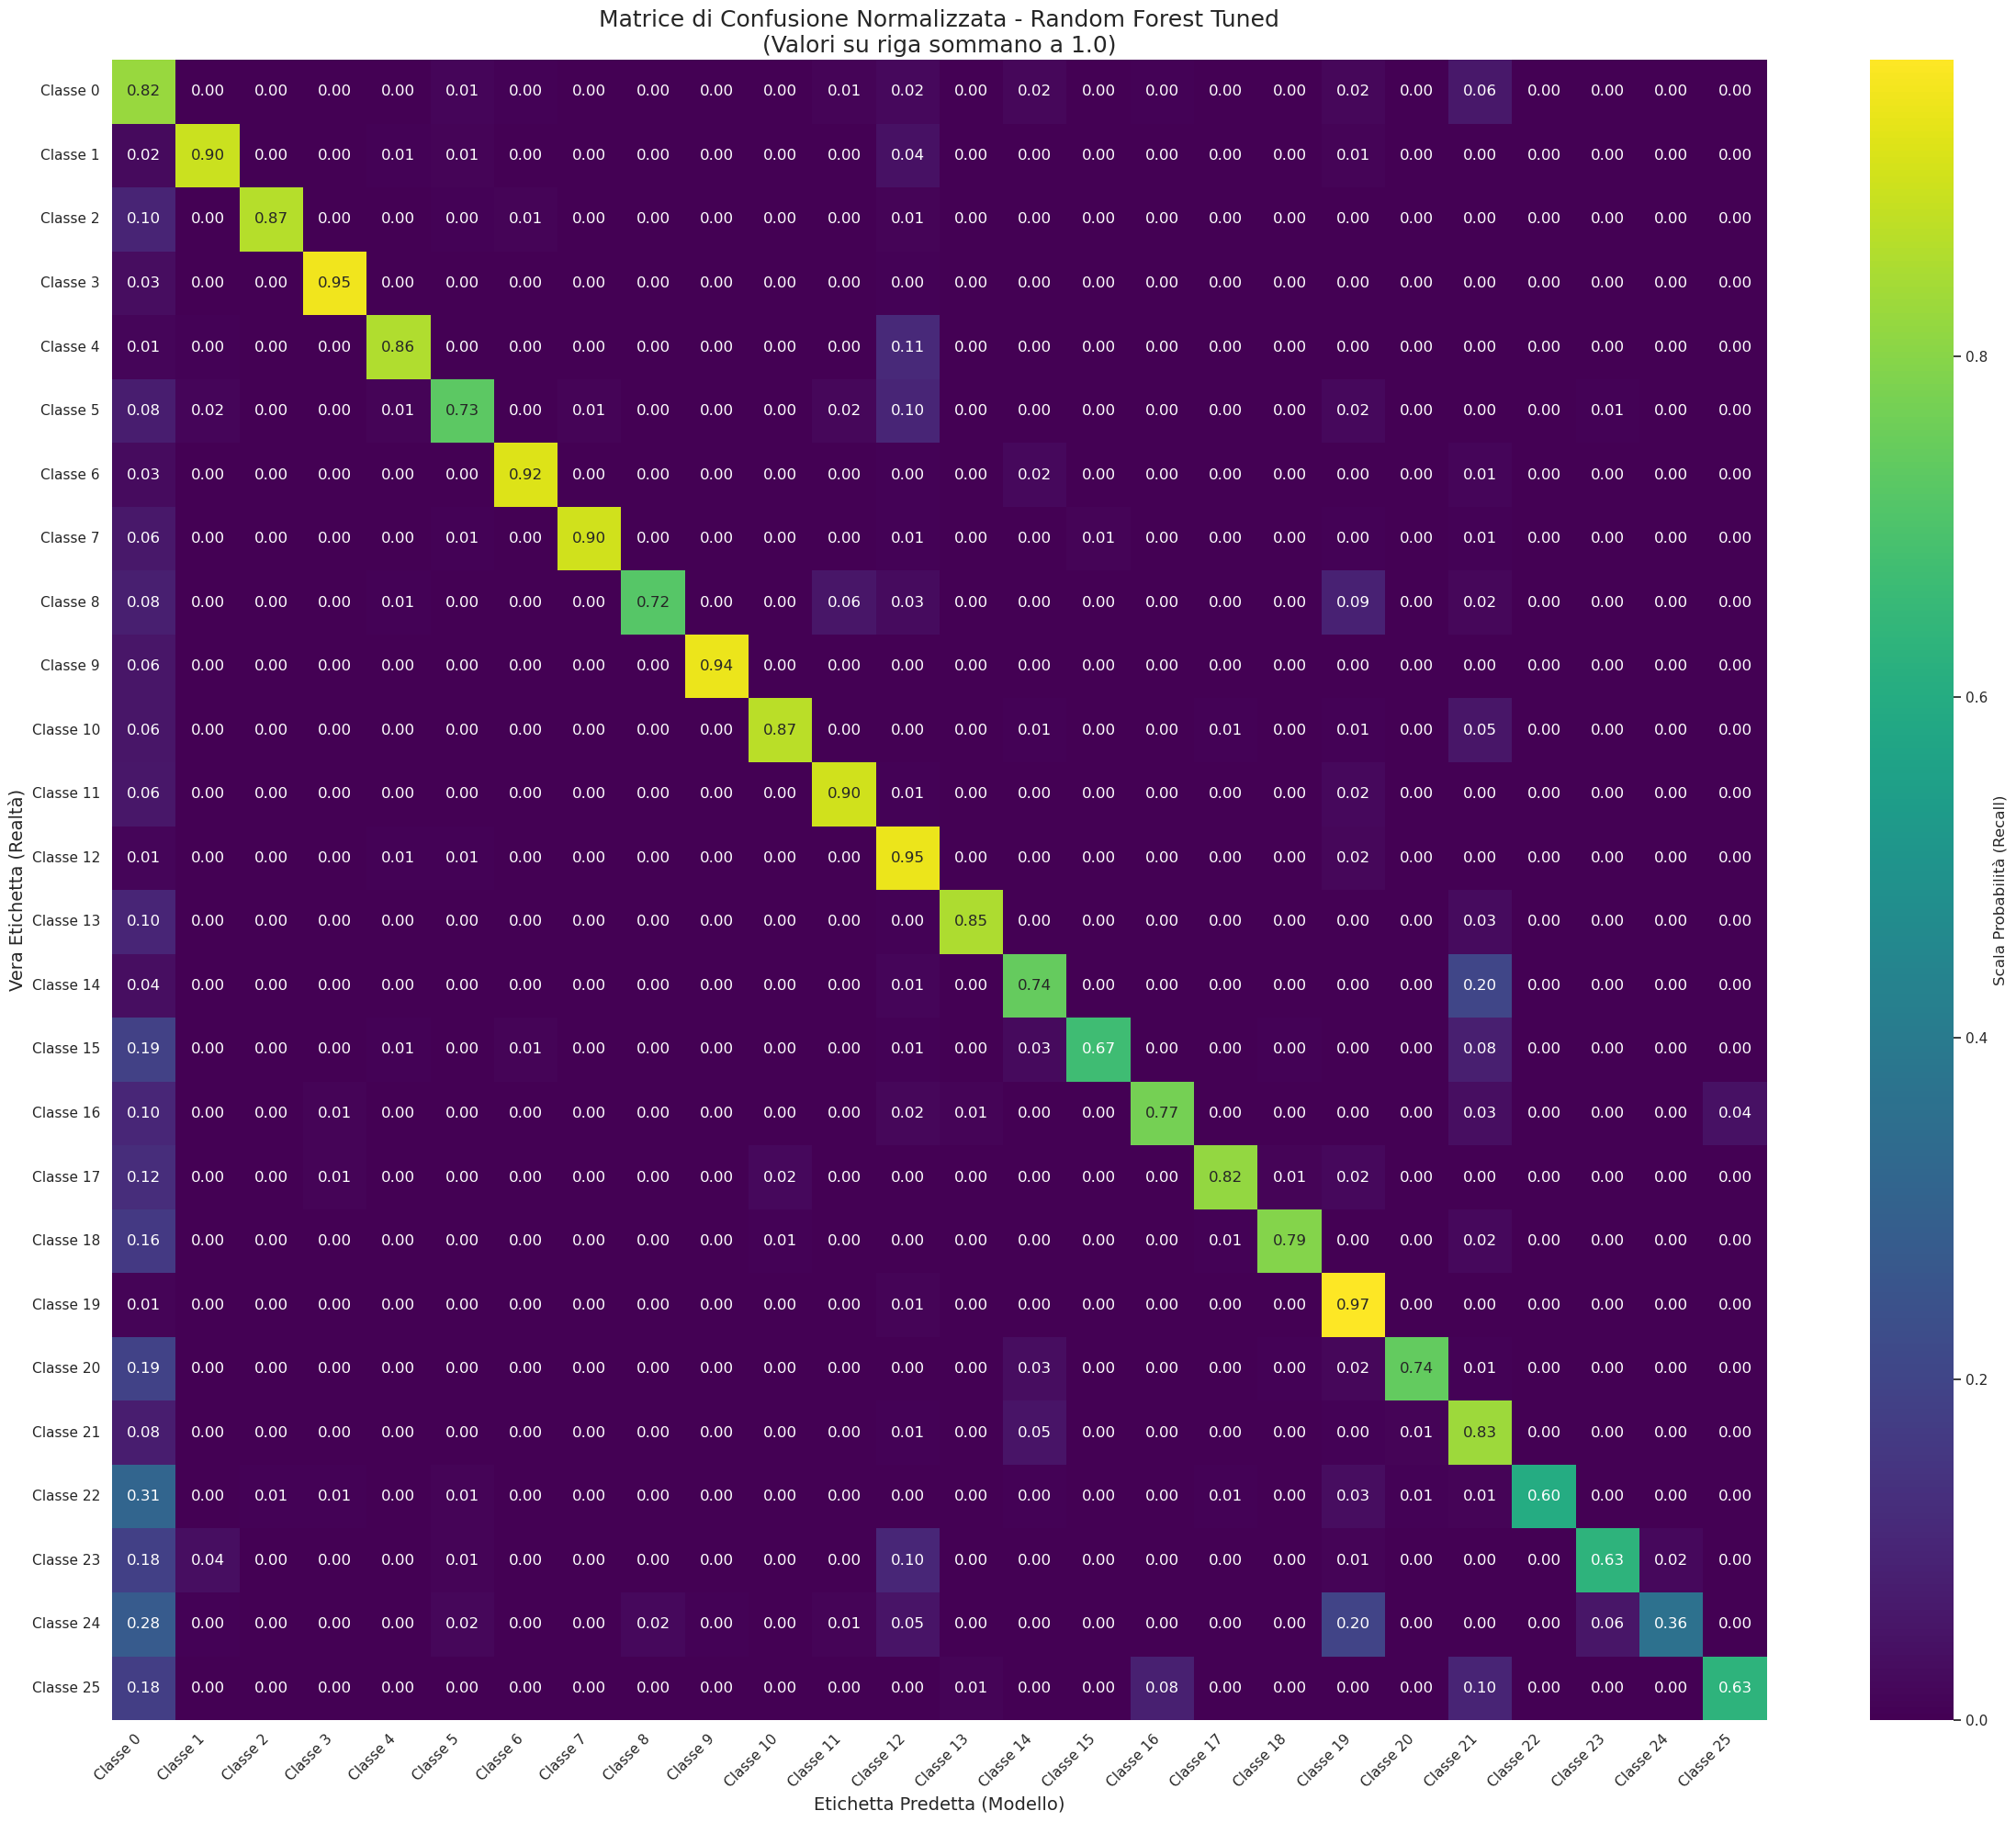

In [8]:

rf_final = RandomForestClassifier(
    n_estimators=500,               
    min_samples_split=2,
    min_samples_leaf=2,
    max_depth=None,                 
    class_weight='balanced_subsample', 
    random_state=42,
    n_jobs=-1                       
)


rf_final.fit(X_train, y_train)

y_pred_final = rf_final.predict(X_test)


target_names = [f"Classes {i}" for i in range(26)]
print(classification_report(y_test, y_pred_final, target_names=target_names))


cm = confusion_matrix(y_test, y_pred_final)

# Normalization per rows
cm_normalized = cm.astype('float') / (cm.sum(axis=1)[:, np.newaxis] + 1e-9)


plt.figure(figsize=(24, 20)) 
sns.set(font_scale=1.0)      

sns.heatmap(cm_normalized, 
            annot=True,             
            fmt='.2f',               
            cmap='viridis',          
            xticklabels=target_names,
            yticklabels=target_names,
            cbar_kws={'label': 'Probability scale (Recall)'})

plt.title('Confusion Matrix normalized - Random Forest Tuned', fontsize=18)
plt.ylabel('True Label', fontsize=14)
plt.xlabel('Predicted Label', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Inizio tuning VELOCE su un campione di 20.000 righe...
Fitting 3 folds for each of 10 candidates, totalling 30 fits


/opt/conda/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/conda/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/conda/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/conda/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/conda/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/conda/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which 

[CV] END ...............................C=0.1668100537200059; total time= 2.4min
[CV] END ...............................C=0.5994842503189409; total time= 2.4min
[CV] END ............................................C=0.001; total time=  45.4s
[CV] END ...............................C=0.5994842503189409; total time= 2.3min
[CV] END ............................................C=0.001; total time=  54.2s
[CV] END ...............................C=0.5994842503189409; total time= 2.3min


/opt/conda/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


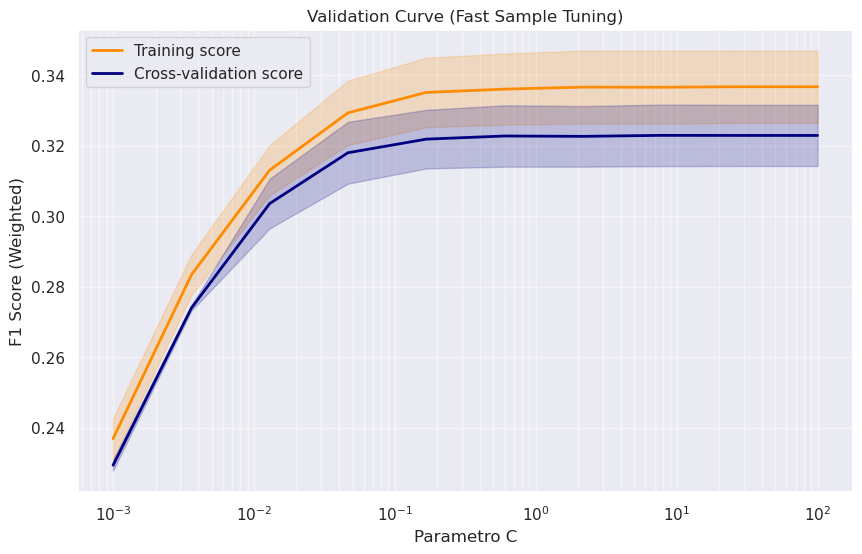

Miglior C trovato: 7.742636826811277
[CV] END ............................................C=0.001; total time=  57.7s
[CV] END ...............................C=2.1544346900318843; total time= 2.4min
[CV] END .............................C=0.003593813663804626; total time= 1.4min
[CV] END ...............................C=2.1544346900318843; total time= 2.4min
[CV] END .............................C=0.003593813663804626; total time= 1.6min
[CV] END ...............................C=2.1544346900318843; total time= 2.3min
[CV] END .............................C=0.003593813663804626; total time= 1.7min
[CV] END ................................C=7.742636826811277; total time= 2.3min


In [9]:

#taking some samples to reduce the elaboration time
idx = np.random.choice(X_train_s.shape[0], 20000, replace=False)
X_train_sample = X_train_s[idx]
y_train_sample = y_train.iloc[idx] 

param_range = np.logspace(-3, 2, 10) 
param_grid = {'C': param_range}


lr = LogisticRegression(
    solver='saga', 
    max_iter=1000,           
    class_weight='balanced', 
    random_state=42,
    n_jobs=-1
)

grid_search_lr = GridSearchCV(
    estimator=lr,
    param_grid=param_grid,
    scoring='f1_weighted',    
    cv=3,
    return_train_score=True,
    n_jobs=-1,
    verbose=2 
)


grid_search_lr.fit(X_train_sample, y_train_sample)


results = grid_search_lr.cv_results_
train_mean = results['mean_train_score']
train_std = results['std_train_score']
test_mean = results['mean_test_score']
test_std = results['std_test_score']
x_axis = param_range

plt.figure(figsize=(10, 6))
plt.plot(x_axis, train_mean, label="Training score", color="darkorange", lw=2)
plt.fill_between(x_axis, train_mean - train_std, train_mean + train_std, alpha=0.2, color="darkorange")
plt.plot(x_axis, test_mean, label="Cross-validation score", color="navy", lw=2)
plt.fill_between(x_axis, test_mean - test_std, test_mean + test_std, alpha=0.2, color="navy")
plt.xscale('log')
plt.xlabel('C Parameter')
plt.ylabel('F1 Score (Weighted)')
plt.title('Validation Curve')
plt.legend(loc="best")
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.show()

print(f"Best C found: {grid_search_lr.best_params_['C']}")

Addestramento Logistic Regression (C=27.8256)...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.


[CV] END ..............................C=0.01291549665014884; total time= 2.3min
[CV] END ................................C=7.742636826811277; total time= 2.3min
[CV] END .............................C=0.046415888336127795; total time= 2.3min
[CV] END ................................C=7.742636826811277; total time= 2.3min
[CV] END ...............................C=0.1668100537200059; total time= 2.4min
[CV] END ...............................C=27.825594022071257; total time= 2.3min
[CV] END ...............................C=0.1668100537200059; total time= 2.4min
[CV] END ...............................C=27.825594022071257; total time= 2.3min
[CV] END .............................C=0.046415888336127795; total time= 2.4min
[CV] END ...............................C=27.825594022071257; total time= 2.3min
[CV] END .............................C=0.046415888336127795; total time= 2.4min
[CV] END ............................................C=100.0; total time= 2.3min
[CV] END ...................

/opt/conda/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


              precision    recall  f1-score   support

    Classe 0       0.60      0.02      0.04     34777
    Classe 1       0.23      0.35      0.28      2942
    Classe 2       0.10      0.43      0.16      1135
    Classe 3       0.15      0.47      0.23      1717
    Classe 4       0.20      0.33      0.25      2383
    Classe 5       0.19      0.21      0.20      3246
    Classe 6       0.19      0.42      0.26      2894
    Classe 7       0.22      0.72      0.33       686
    Classe 8       0.11      0.37      0.16      1455
    Classe 9       0.46      0.89      0.61      1607
   Classe 10       0.26      0.60      0.36      1730
   Classe 11       0.23      0.37      0.28      4477
   Classe 12       0.40      0.19      0.25     11171
   Classe 13       0.06      0.14      0.08      1604
   Classe 14       0.24      0.16      0.20      4426
   Classe 15       0.13      0.13      0.13      1542
   Classe 16       0.07      0.26      0.10      1102
   Classe 17       0.38    

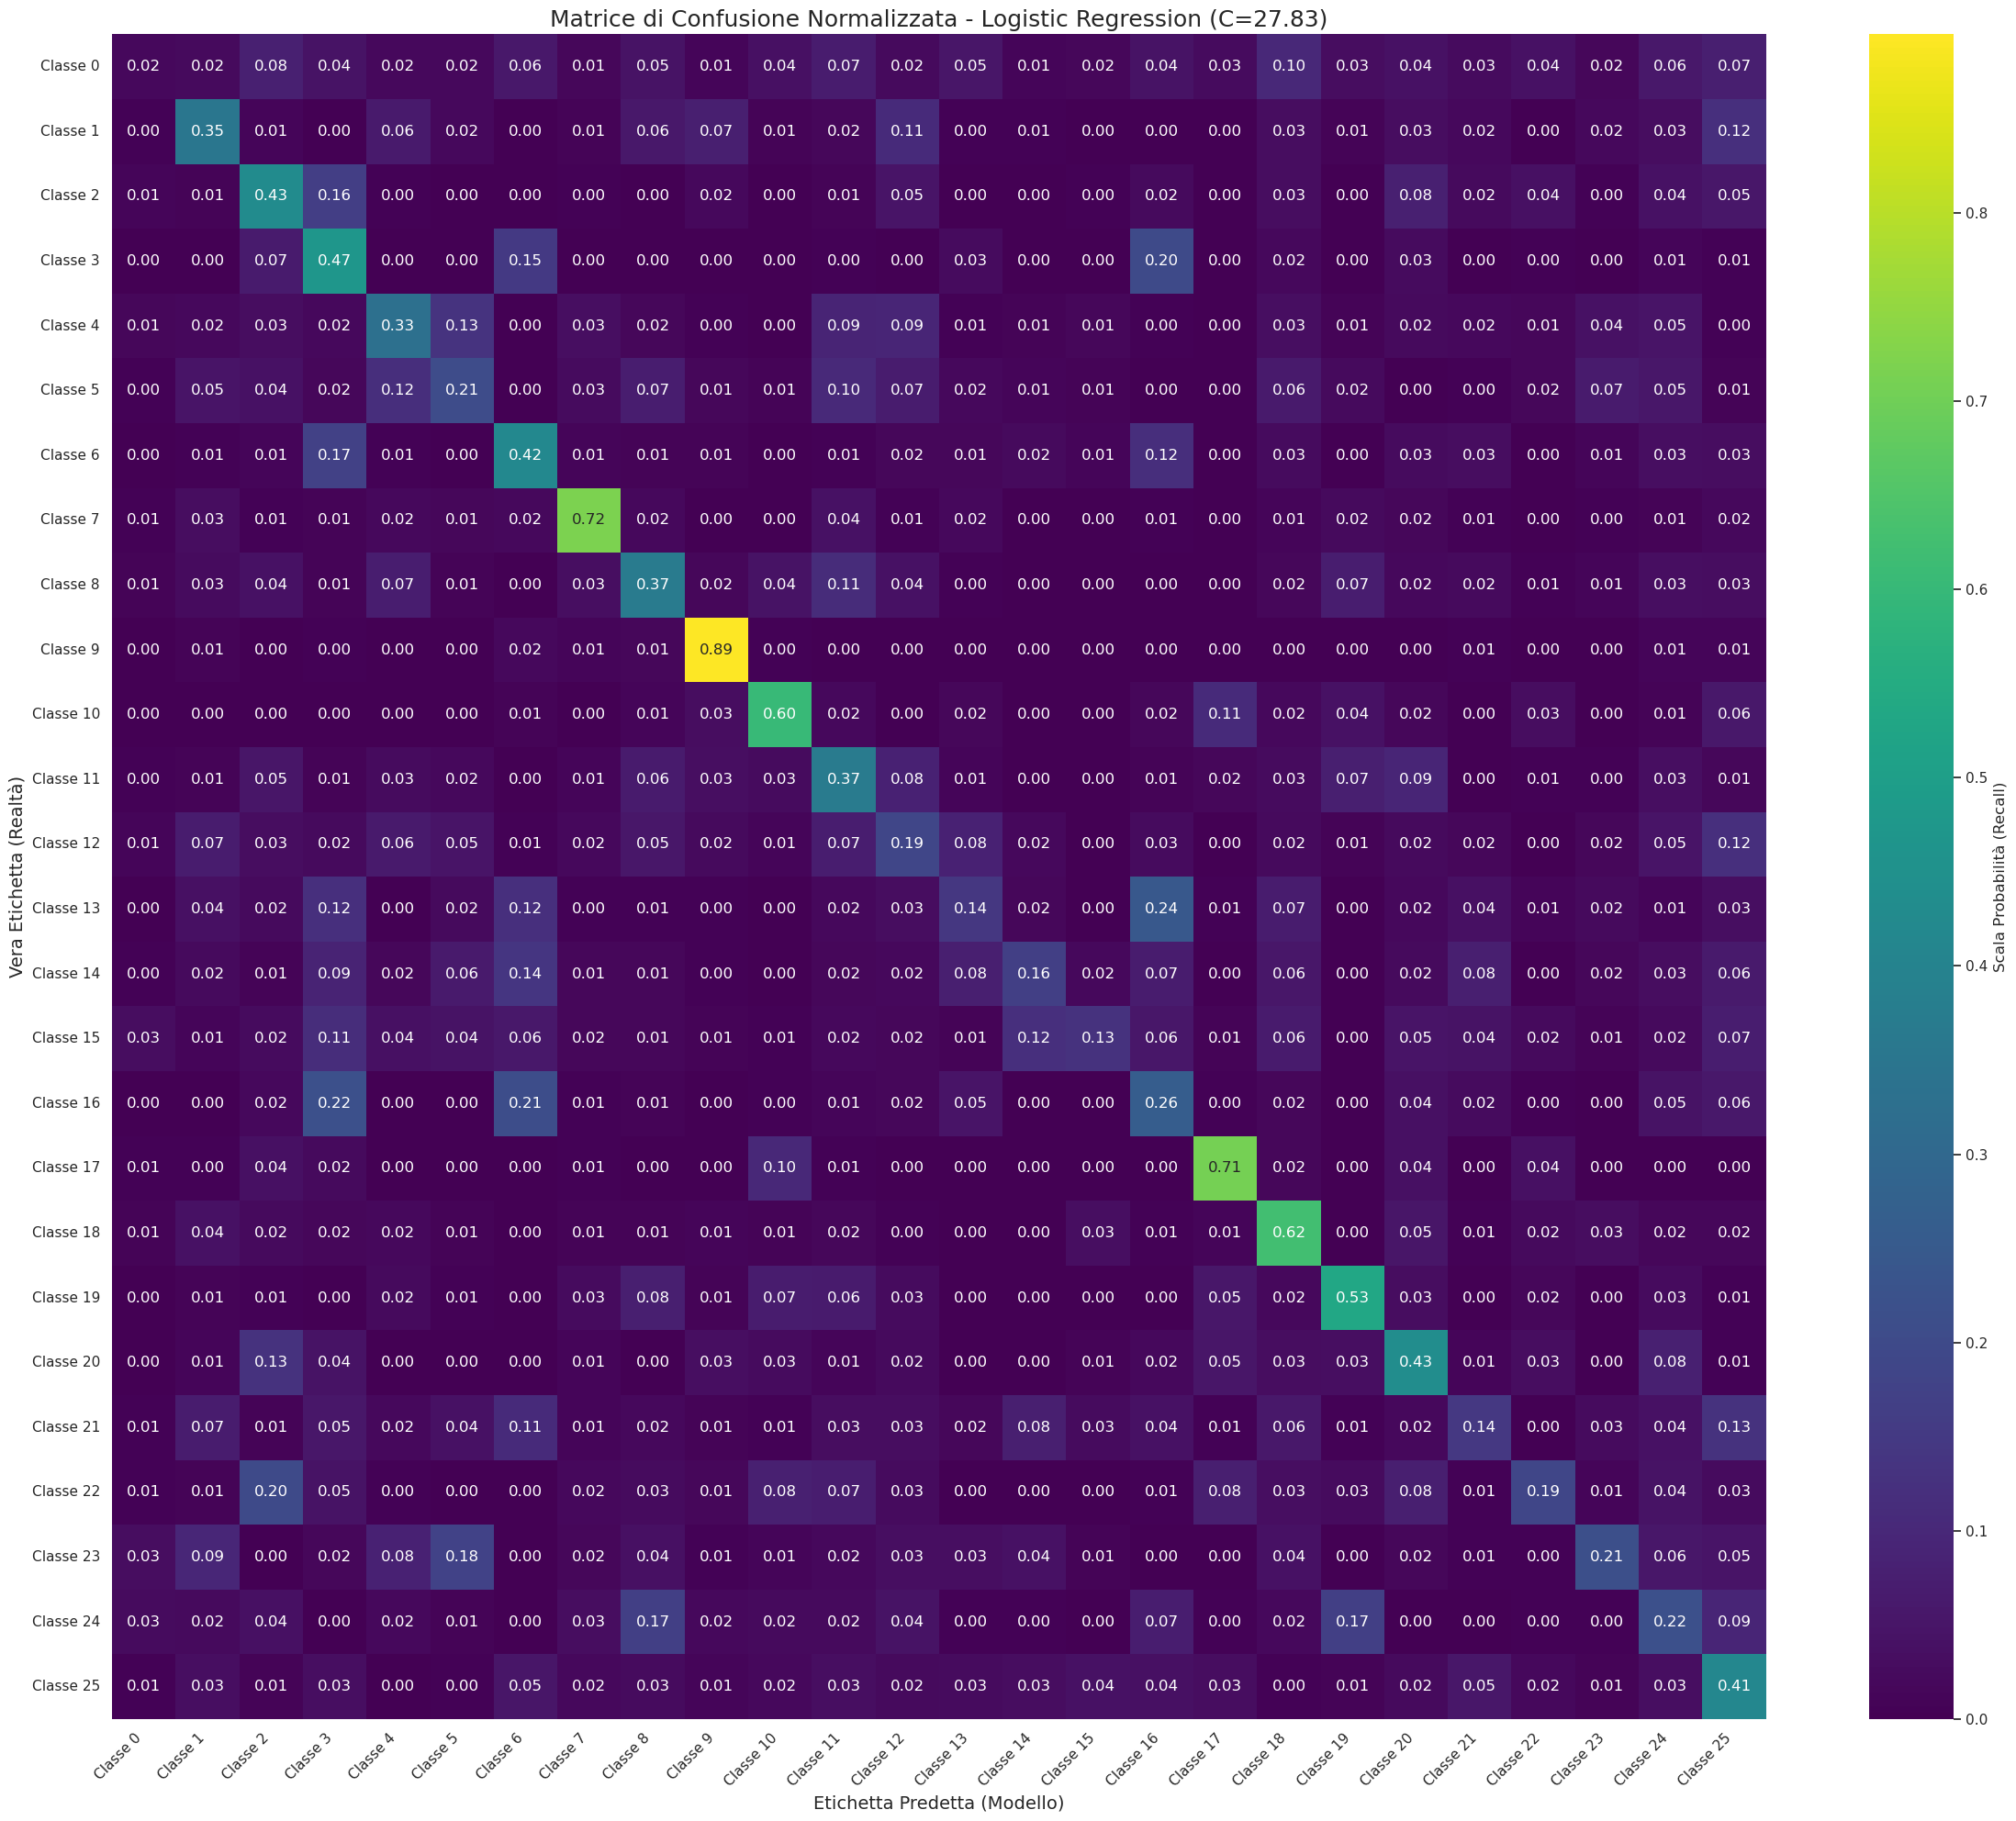

In [10]:

best_C = 27.825594022071257  # best C found

lr_final = LogisticRegression(
    C=best_C,
    solver='saga',
    class_weight='balanced',
    max_iter=100,       
    n_jobs=-1,
    random_state=42,
    verbose=1           
)


lr_final.fit(X_train_s, y_train)

y_pred_lr = lr_final.predict(X_test_s)


target_names = [f"Classes {i}" for i in range(26)]
print(classification_report(y_test, y_pred_lr, target_names=target_names))


cm = confusion_matrix(y_test, y_pred_lr)

cm_normalized = cm.astype('float') / (cm.sum(axis=1)[:, np.newaxis] + 1e-9)

plt.figure(figsize=(24, 20))
sns.set(font_scale=1.0)

sns.heatmap(cm_normalized, 
            annot=True,              
            fmt='.2f',               
            cmap='viridis',          
            xticklabels=target_names,
            yticklabels=target_names,
            cbar_kws={'label': 'Probability scale (Recall)'})

plt.title(f'Normalized Confusion Matrix - Logistic Regression (C={best_C:.2f})', fontsize=18)
plt.ylabel('True Label (Realtà)', fontsize=14)
plt.xlabel('Predicted Label (Modello)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

2. Estrazione campione di 20000 righe per tuning...
3. Inizio Grid Search (sul campione)...
Fitting 3 folds for each of 16 candidates, totalling 48 fits

   Migliori Parametri trovati: {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'distance'}

4. Generazione Validation Curve per n_neighbors...


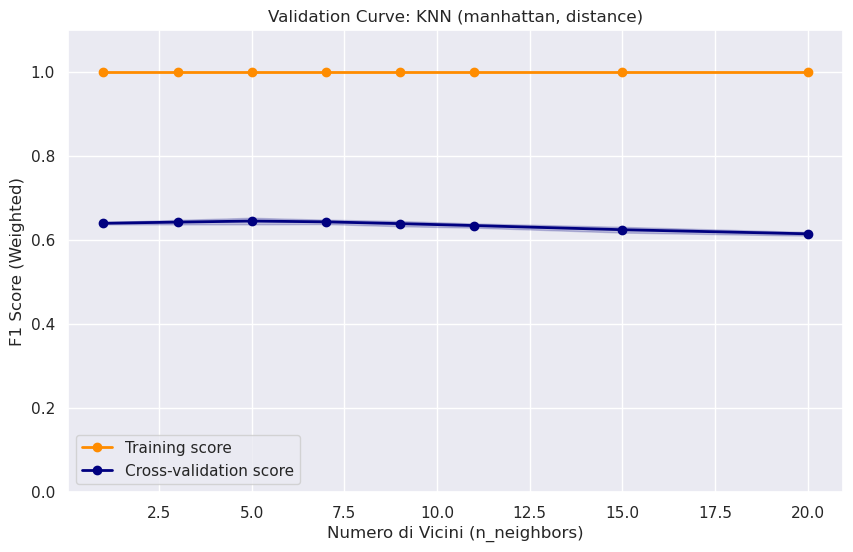


5. Addestramento modello finale su TUTTO il dataset...
6. Generazione predizioni sul Test Set (questo impiegherà qualche minuto)...

--- CLASSIFICATION REPORT (KNN Optimized - Selected Features) ---
              precision    recall  f1-score   support

    Classe 0       0.67      0.63      0.65     34777
    Classe 1       0.60      0.58      0.59      2942
    Classe 2       0.36      0.35      0.36      1135
    Classe 3       0.58      0.56      0.57      1717
    Classe 4       0.52      0.50      0.51      2383
    Classe 5       0.47      0.30      0.37      3246
    Classe 6       0.54      0.49      0.51      2894
    Classe 7       0.71      0.74      0.72       686
    Classe 8       0.39      0.29      0.33      1455
    Classe 9       0.94      0.91      0.93      1607
   Classe 10       0.62      0.73      0.67      1730
   Classe 11       0.55      0.50      0.52      4477
   Classe 12       0.66      0.69      0.67     11171
   Classe 13       0.43      0.43      0.43

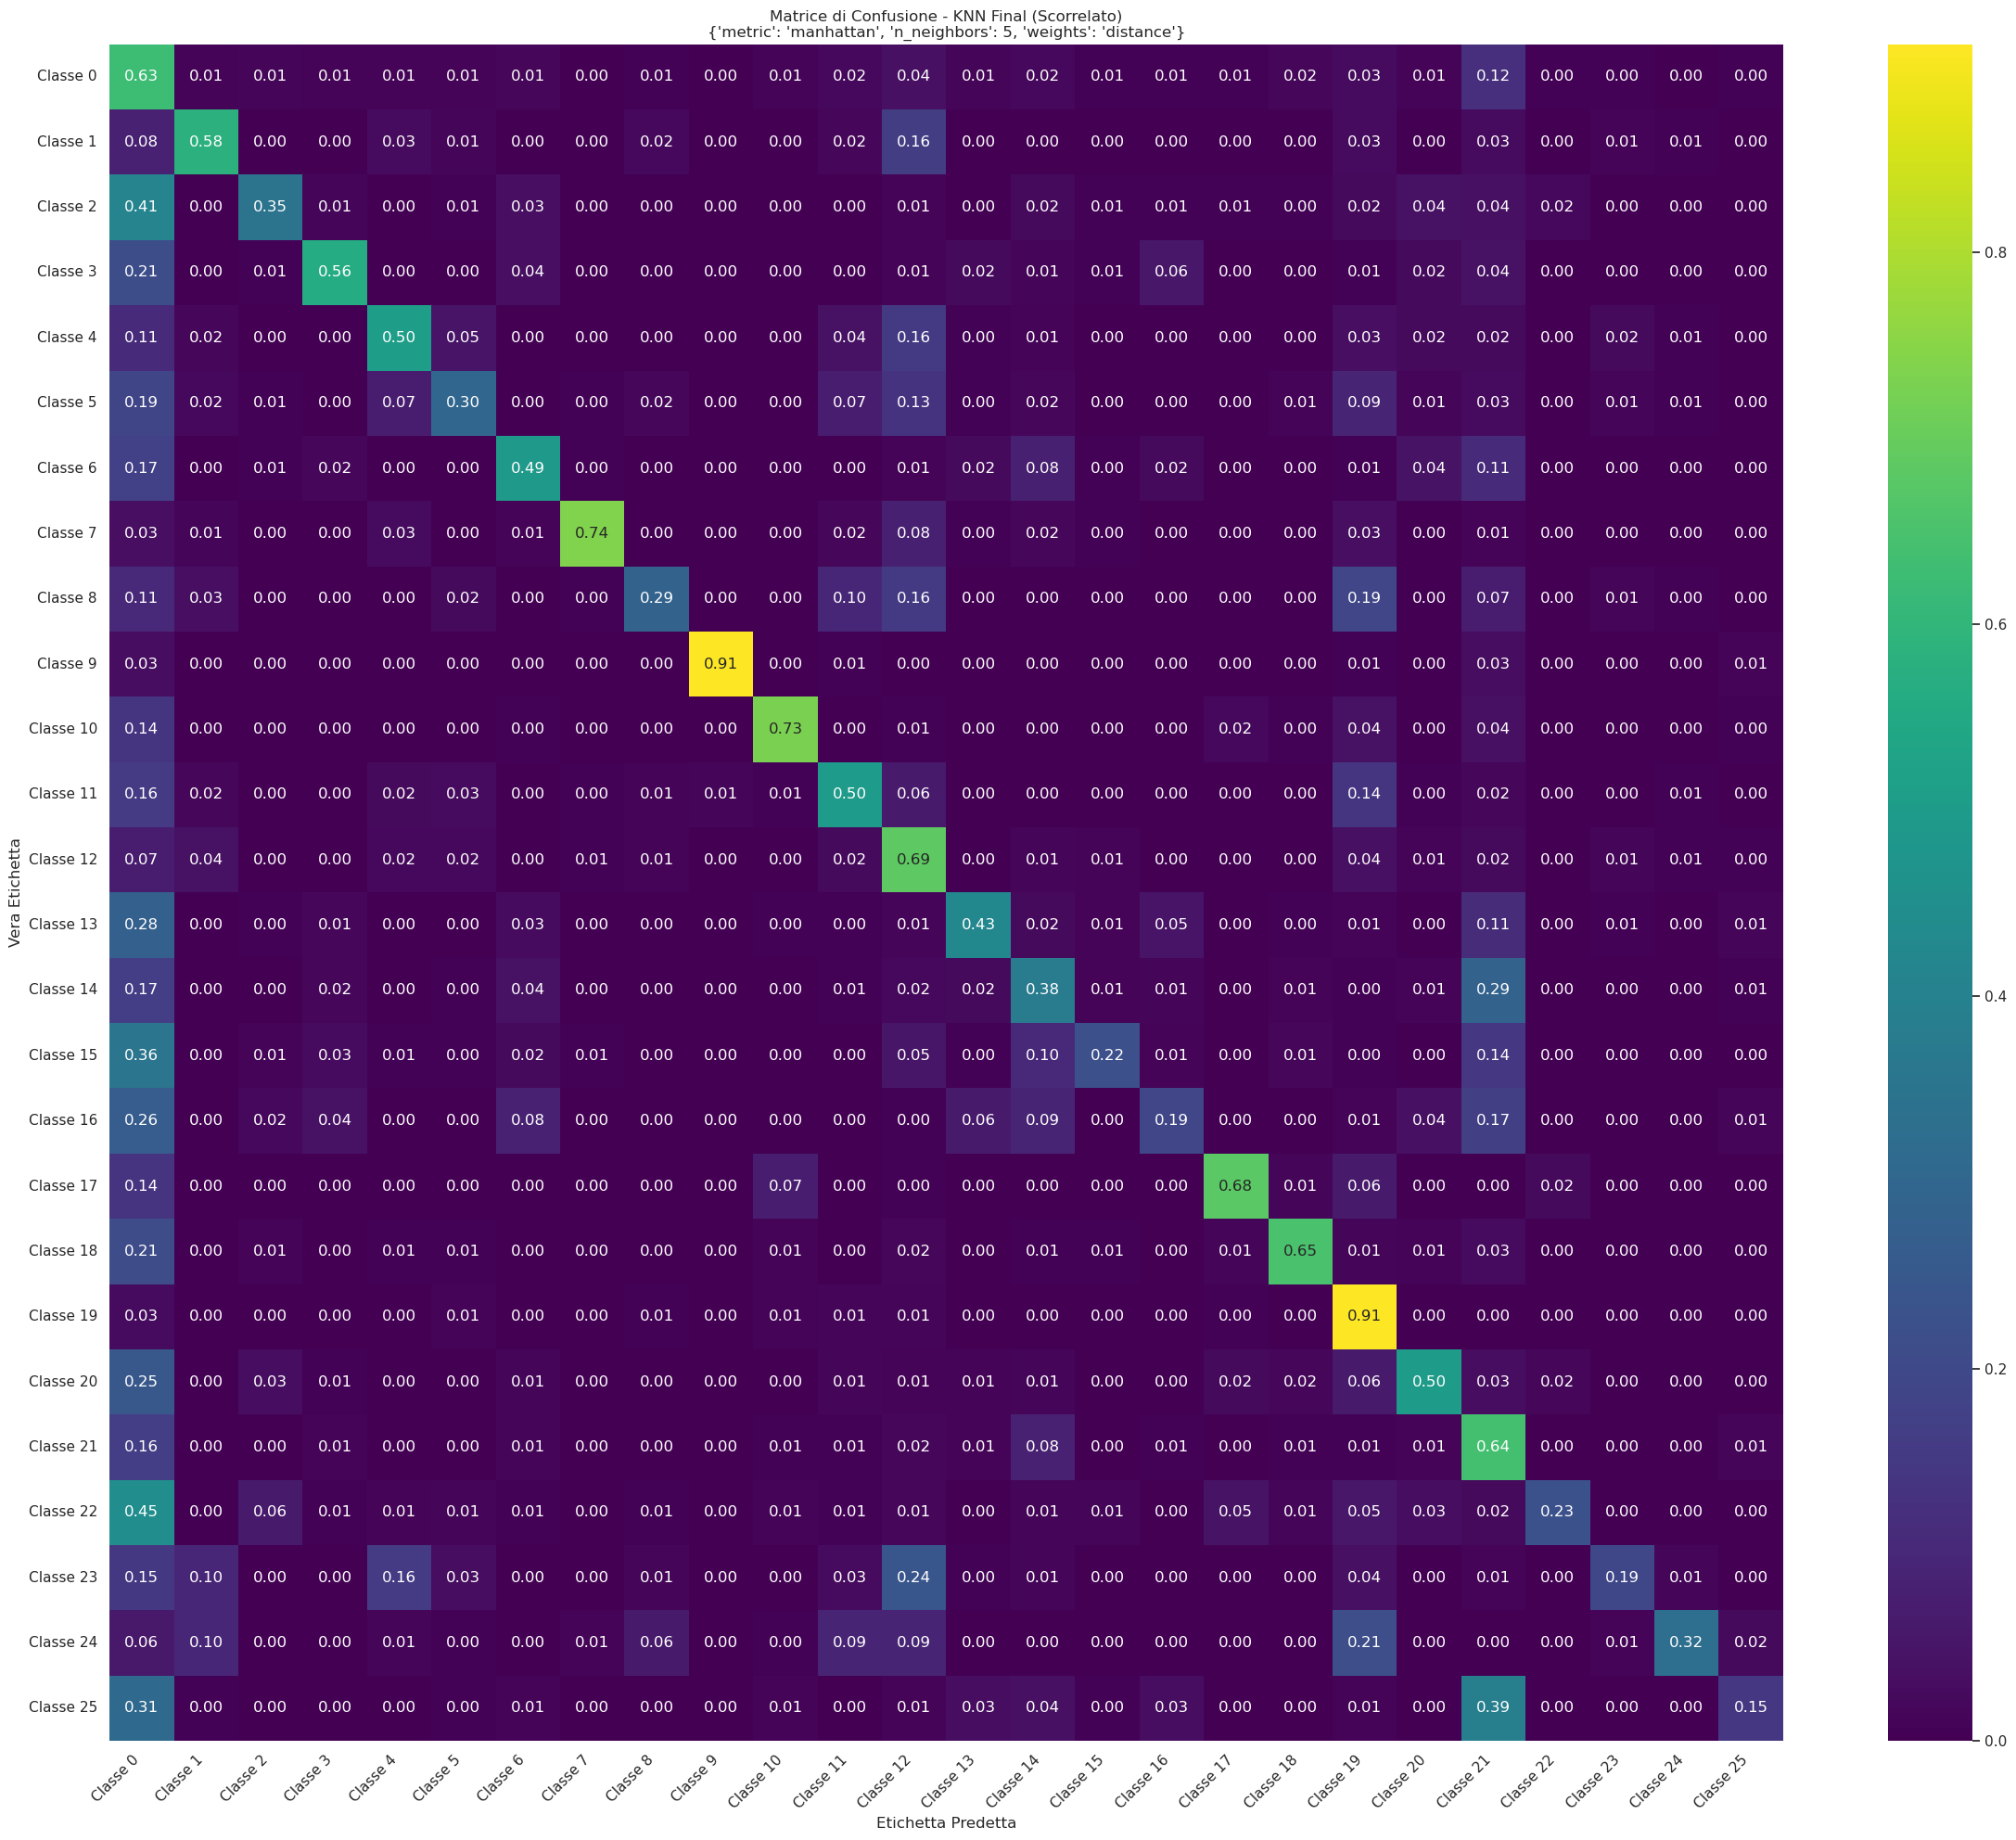

In [14]:
#sampling to reduce elab. time
sample_size = 20000

idx = np.random.choice(X_train_s.shape[0], sample_size, replace=False)
X_sample = X_train_s[idx]


if hasattr(y_train, 'iloc'):
    y_sample = y_train.iloc[idx]
else:
    y_sample = y_train[idx]

param_grid_knn = {
    'n_neighbors': [3, 5, 7, 11],          
    'weights': ['uniform', 'distance'],    
    'metric': ['manhattan', 'euclidean']   
}
 
knn = KNeighborsClassifier(n_jobs=-1)

grid_search_knn = GridSearchCV(
    estimator=knn,
    param_grid=param_grid_knn,
    cv=3,                 
    scoring='f1_weighted',
    verbose=1,
    n_jobs=-1
)

grid_search_knn.fit(X_sample, y_sample)

print(f"\n   Best parameters found: {grid_search_knn.best_params_}")
best_metric = grid_search_knn.best_params_['metric']
best_weights = grid_search_knn.best_params_['weights']




param_range = [1, 3, 5, 7, 9, 11, 15, 20]
knn_for_curve = KNeighborsClassifier(metric=best_metric, weights=best_weights, n_jobs=-1)

train_scores, test_scores = validation_curve(
    knn_for_curve,
    X_sample, y_sample,          
    param_name="n_neighbors",
    param_range=param_range,
    cv=3,
    scoring="f1_weighted",
    n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)


plt.figure(figsize=(10, 6))
plt.title(f"Validation Curve: KNN ({best_metric}, {best_weights})")
plt.xlabel("n_neighbors")
plt.ylabel("F1 Score (Weighted)")
plt.ylim(0.0, 1.1)
lw = 2

plt.plot(param_range, train_mean, label="Training score", color="darkorange", lw=lw, marker='o')
plt.fill_between(param_range, train_mean - train_std, train_mean + train_std, alpha=0.2, color="darkorange")

plt.plot(param_range, test_mean, label="Cross-validation score", color="navy", lw=lw, marker='o')
plt.fill_between(param_range, test_mean - test_std, test_mean + test_std, alpha=0.2, color="navy")

plt.legend(loc="best")
plt.grid(True)
plt.show()


best_params = grid_search_knn.best_params_

final_knn = KNeighborsClassifier(
    n_neighbors=best_params['n_neighbors'],
    weights=best_params['weights'],
    metric=best_params['metric'],
    n_jobs=-1
)


final_knn.fit(X_train_s, y_train)
 
y_pred_knn = final_knn.predict(X_test_s)

target_names = [f"Classes {i}" for i in range(26)]
print(classification_report(y_test, y_pred_knn, target_names=target_names))


cm = confusion_matrix(y_test, y_pred_knn)
cm_normalized = cm.astype('float') / (cm.sum(axis=1)[:, np.newaxis] + 1e-9)

plt.figure(figsize=(24, 20))
sns.set(font_scale=1.0)
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='viridis',
            xticklabels=target_names, yticklabels=target_names)
plt.title(f"Confusion matrix - KNN Final \n{best_params}")
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()